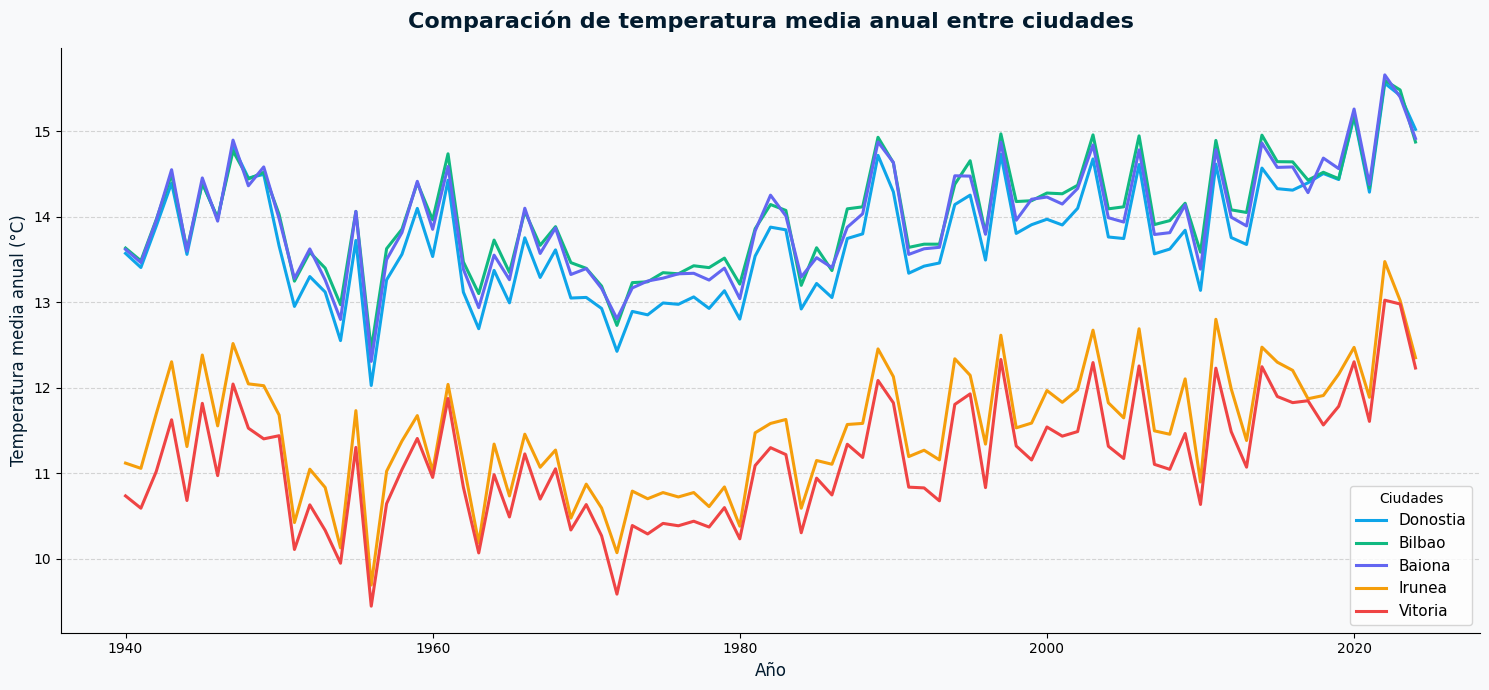

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from variables import csv_list

dfs = {}

# Cargar datos
for csv in csv_list:
    nombre = csv.split('_')[1].replace('.csv', '')
    dfs[nombre] = pd.read_csv(csv)

# ───────────────────────────────────────────────
# VARIABLE A COMPARAR
# Cambia esta línea según la hipótesis
variable = 'temperature_2m_mean'   # EJEMPLO: temperatura media anual
agg_func = 'mean'                  # 'sum' si es precipitación
ylabel = 'Temperatura media anual (°C)'
titulo = 'Comparación de temperatura media anual entre ciudades'
# ───────────────────────────────────────────────

# Preparar figura
plt.figure(figsize=(15, 7))
plt.gca().set_facecolor('#F8F9FA')
plt.gcf().patch.set_facecolor('#F8F9FA')

colores = {
    'donostia': '#0EA5E9',
    'bilbao':   '#10B981',
    'baiona':   '#6366F1',
    'irunea':   '#F59E0B',
    'vitoria':  '#EF4444'
}

# Graficar cada ciudad
for ciudad, df in dfs.items():

    if agg_func == 'mean':
        serie = df.groupby('año')[variable].mean()
    else:
        serie = df.groupby('año')[variable].sum()

    años = serie.index
    valores = serie.values

    plt.plot(años, valores, label=ciudad.capitalize(),
             linewidth=2.2, color=colores[ciudad])

# Estilo
plt.title(titulo, fontsize=16, fontweight='bold', color='#021B2E', pad=15)
plt.xlabel('Año', fontsize=12, color='#021B2E')
plt.ylabel(ylabel, fontsize=12, color='#021B2E')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ciudades', fontsize=11)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()

plt.savefig('comparativa_ciudades_H3.png', dpi=180, bbox_inches='tight')
plt.show()
